# Notebook 01: Exploratory Data Analysis (EDA)
**Project**: Explainable Student Performance Prediction with an LLM Explanation Layer  
**Dataset**: `data/student_performance_dataset.csv`  
**Target Variable**: `Final_Exam_Score` (Continuous, 50–77) & `Pass_Fail` (Binary: Pass $\ge 60$, Fail $< 60$)  

### Notebook Goals:
1. Verify dataset structure, data types, and check for missing values.
2. Analyze the distribution of `Final_Exam_Score`, check min/max boundaries, and detect any potential outliers (> 100 or < 0).
3. Compute and visualize Pearson correlation between numerical predictors and `Final_Exam_Score`.
4. Inspect categorical features (`Gender`, `Parental_Education_Level`, `Internet_Access_at_Home`, `Extracurricular_Activities`) via boxplots against `Final_Exam_Score`.
5. Save high-resolution figures to `reports/figures/`.
6. Summarize the 5 most critical insights in plain English.


In [1]:
# Imports & Global Configuration
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Project directories
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Fixed seed for reproducibility (Project Rule 4)
RANDOM_STATE = 42

print("Setup completed successfully.")
print("Figures output directory:", FIGURES_DIR.resolve())


Setup completed successfully.
Figures output directory: /Users/pratham/Coding/Student performance/reports/figures


## 1. Data Ingestion & Schema Inspection
We load `student_performance_dataset.csv` and inspect its shape, columns, and variable types.


In [2]:
# Load dataset (robust path resolution)
data_path = Path("../data/student_performance_dataset.csv")
if not data_path.exists():
    data_path = Path("data/student_performance_dataset.csv")
if not data_path.exists():
    data_path = Path("student_performance_dataset.csv")

df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Data Types & Memory Usage:")
print(df.info())

df.head(10)


Dataset Shape: 708 rows x 10 columns

Data Types & Memory Usage:
<class 'pandas.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    str    
 1   Gender                      708 non-null    str    
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    str    
 6   Internet_Access_at_Home     708 non-null    str    
 7   Extracurricular_Activities  708 non-null    str    
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    str    
dtypes: float64(1), int64(3), str(6)
memory usage: 73.2 KB
None


,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass
5,S417,Male,30,84.159193,77,Masters,Yes,No,61,Pass
6,S302,Male,24,89.389494,95,High School,Yes,Yes,61,Pass
7,S009,Male,31,50.683598,78,Masters,No,No,50,Fail
8,S044,Female,34,80.863186,94,PhD,No,Yes,65,Pass
9,S331,Male,27,65.496846,86,High School,Yes,No,55,Fail


## 2. Missing Value & Data Quality Audit
We check for missing values across all columns to evaluate whether imputation will be necessary.


findfont: Failed to find font weight semibold for Helvetica, now using 700.


Missing Values Summary:
                    Column Data_Type  Missing_Count  Missing_Percentage
                Student_ID       str              0                 0.0
                    Gender       str              0                 0.0
      Study_Hours_per_Week     int64              0                 0.0
           Attendance_Rate   float64              0                 0.0
          Past_Exam_Scores     int64              0                 0.0
  Parental_Education_Level       str              0                 0.0
   Internet_Access_at_Home       str              0                 0.0
Extracurricular_Activities       str              0                 0.0
          Final_Exam_Score     int64              0                 0.0
                 Pass_Fail       str              0                 0.0


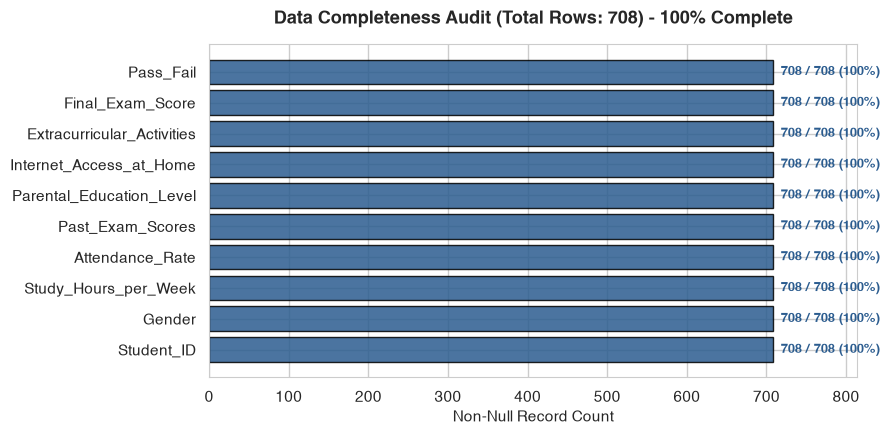

In [3]:
# Check missing values per column
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': [str(t) for t in df.dtypes],
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_pct.values
})

print("Missing Values Summary:")
print(missing_df.to_string(index=False))

# Visualization of completeness
fig, ax = plt.subplots(figsize=(9, 4.5))
non_null_counts = len(df) - missing_counts
bars = ax.barh(df.columns, non_null_counts, color='#2b5c8f', edgecolor='black', alpha=0.85)
ax.set_xlim(0, len(df) * 1.15)
ax.set_xlabel("Non-Null Record Count", fontsize=11)
ax.set_title(f"Data Completeness Audit (Total Rows: {len(df)}) - 100% Complete", fontsize=13, weight='bold', pad=15)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 10, bar.get_y() + bar.get_height() / 2, f"{int(width)} / {len(df)} (100%)",
            va='center', fontsize=9, weight='semibold', color='#2b5c8f')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_missing_values_and_overview.png", dpi=300)
plt.show()


## 3. Target Variable Analysis: `Final_Exam_Score`
We analyze the distribution, spread, central tendency, and outlier limits of `Final_Exam_Score`.
We also evaluate the relationship between `Final_Exam_Score` and the `Pass_Fail` classification column.


Target Variable (Final_Exam_Score) Statistics:
count    708.000000
mean      58.771186
std        6.705877
min       50.000000
25%       52.000000
50%       59.500000
75%       64.000000
max       77.000000
Name: Final_Exam_Score, dtype: float64

Min: 50, Max: 77, Mean: 58.77, Median: 59.50, Std: 6.71

Flagged values > 100: 0
Flagged values < 0: 0

Final_Exam_Score by Pass_Fail status:
           count  min  max       mean       std
Pass_Fail                                      
Fail         354   50   59  52.980226  3.216838
Pass         354   60   77  64.562147  3.529372


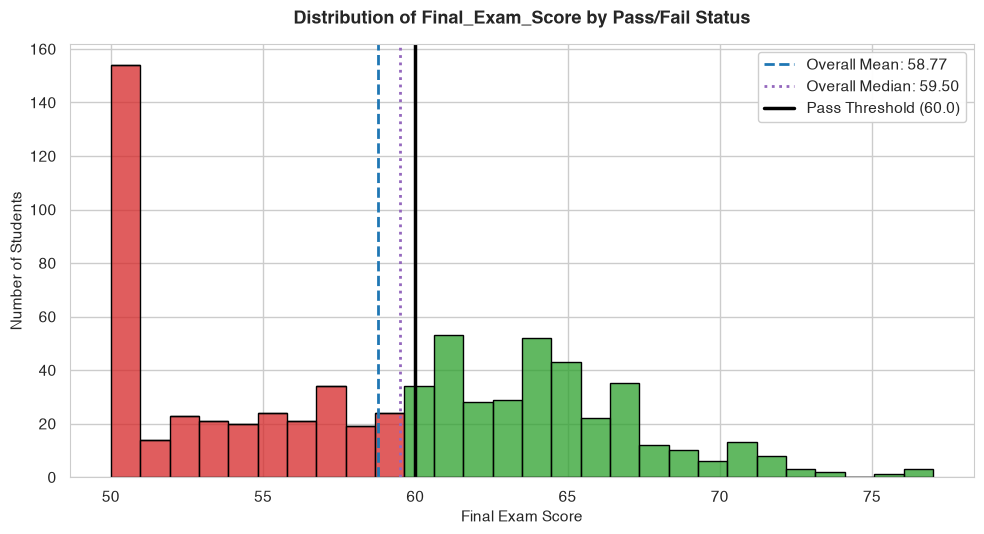

In [4]:
# Summary Statistics of Final_Exam_Score
stats = df['Final_Exam_Score'].describe()
mean_val = df['Final_Exam_Score'].mean()
median_val = df['Final_Exam_Score'].median()
std_val = df['Final_Exam_Score'].std()
min_val = df['Final_Exam_Score'].min()
max_val = df['Final_Exam_Score'].max()

print("Target Variable (Final_Exam_Score) Statistics:")
print(stats)
print(f"\nMin: {min_val}, Max: {max_val}, Mean: {mean_val:.2f}, Median: {median_val:.2f}, Std: {std_val:.2f}")

# Outlier verification
outliers_above_100 = df[df['Final_Exam_Score'] > 100]
outliers_below_0 = df[df['Final_Exam_Score'] < 0]

print(f"\nFlagged values > 100: {len(outliers_above_100)}")
print(f"Flagged values < 0: {len(outliers_below_0)}")

# Relationship with Pass_Fail threshold
print("\nFinal_Exam_Score by Pass_Fail status:")
print(df.groupby('Pass_Fail')['Final_Exam_Score'].agg(['count', 'min', 'max', 'mean', 'std']))

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(data=df, x='Final_Exam_Score', hue='Pass_Fail', multiple='stack',
             bins=28, palette={'Pass': '#2ca02c', 'Fail': '#d62728'}, alpha=0.75, edgecolor='black', ax=ax)

ax.axvline(mean_val, color='#1f77b4', linestyle='--', linewidth=2, label=f'Overall Mean: {mean_val:.2f}')
ax.axvline(median_val, color='#9467bd', linestyle=':', linewidth=2, label=f'Overall Median: {median_val:.2f}')
ax.axvline(60.0, color='black', linestyle='-', linewidth=2.5, label='Pass Threshold (60.0)')

ax.set_title("Distribution of Final_Exam_Score by Pass/Fail Status", fontsize=13, weight='bold', pad=15)
ax.set_xlabel("Final Exam Score", fontsize=11)
ax.set_ylabel("Number of Students", fontsize=11)
ax.legend(frameon=True, facecolor='white', framealpha=0.95)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_final_exam_score_distribution.png", dpi=300)
plt.show()


## 4. Correlation of Numeric Features with `Final_Exam_Score`
We assess the linear relationship between continuous predictors (`Study_Hours_per_Week`, `Attendance_Rate`, `Past_Exam_Scores`) and `Final_Exam_Score`.


findfont: Failed to find font weight semibold for Helvetica, now using 700.


Correlation Matrix:
                      Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
Study_Hours_per_Week                1.0000          -0.0082           -0.0148   
Attendance_Rate                    -0.0082           1.0000            0.0004   
Past_Exam_Scores                   -0.0148           0.0004            1.0000   
Final_Exam_Score                    0.3704           0.4605            0.4895   

                      Final_Exam_Score  
Study_Hours_per_Week            0.3704  
Attendance_Rate                 0.4605  
Past_Exam_Scores                0.4895  
Final_Exam_Score                1.0000  

Ranked Correlations with Final_Exam_Score:
Past_Exam_Scores        0.4895
Attendance_Rate         0.4605
Study_Hours_per_Week    0.3704
Name: Final_Exam_Score, dtype: float64


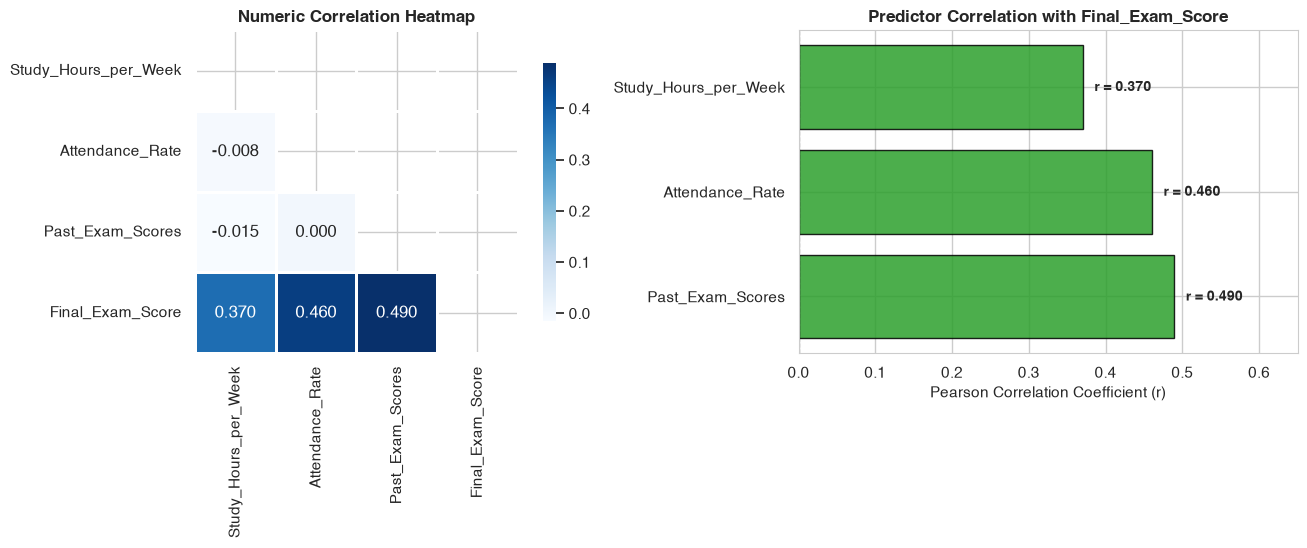

In [5]:
# Identify numeric columns (excluding non-predictive identifiers)
numeric_cols = ['Study_Hours_per_Week', 'Attendance_Rate', 'Past_Exam_Scores', 'Final_Exam_Score']
corr_matrix = df[numeric_cols].corr()

target_corrs = corr_matrix['Final_Exam_Score'].drop('Final_Exam_Score').sort_values(ascending=False)

print("Correlation Matrix:")
print(corr_matrix.round(4))
print("\nRanked Correlations with Final_Exam_Score:")
print(target_corrs.round(4))

# 2-Panel Plot: Correlation Heatmap + Ranked Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".3f", cmap="Blues",
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title("Numeric Correlation Heatmap", fontsize=12, weight='bold')

# Bar chart
colors = ['#2ca02c' if x > 0 else '#d62728' for x in target_corrs.values]
bars = axes[1].barh(target_corrs.index, target_corrs.values, color=colors, edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlim(0, 0.65)
axes[1].set_title("Predictor Correlation with Final_Exam_Score", fontsize=12, weight='bold')
axes[1].set_xlabel("Pearson Correlation Coefficient (r)", fontsize=11)

for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 0.015, bar.get_y() + bar.get_height() / 2, f"r = {width:.3f}",
                 va='center', fontsize=10, weight='semibold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_numeric_correlations.png", dpi=300)
plt.show()


## 5. Categorical Predictors vs. `Final_Exam_Score`
We evaluate the distribution and variance of `Final_Exam_Score` across categorical features:
`Gender`, `Parental_Education_Level`, `Internet_Access_at_Home`, and `Extracurricular_Activities`.


/var/folders/h9/2rbd69ms1fn0w259j863krnw0000gn/T/ipykernel_15642/1768483490.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/h9/2rbd69ms1fn0w259j863krnw0000gn/T/ipykernel_15642/1768483490.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/h9/2rbd69ms1fn0w259j863krnw0000gn/T/ipykernel_15642/1768483490.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/h9/2rbd69ms1fn0w259j863krnw0000gn/T/ipykernel_15642/1768483490.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

=== Group Statistics: Parental_Education_Level ===
                           mean  median  count
Parental_Education_Level                      
High School               58.13    59.0    183
Bachelors                 59.13    60.0    189
Masters                   59.59    61.0    171
PhD                       58.23    58.0    165

=== Group Statistics: Extracurricular_Activities ===
                             mean  median  count
Extracurricular_Activities                      
No                          58.33    58.0    361
Yes                         59.23    60.0    347

=== Group Statistics: Internet_Access_at_Home ===
                          mean  median  count
Internet_Access_at_Home                      
No                       58.85    60.0    381
Yes                      58.68    58.0    327

=== Group Statistics: Gender ===
         mean  median  count
Gender                      
Female  58.98    60.0    375
Male    58.54    59.0    333



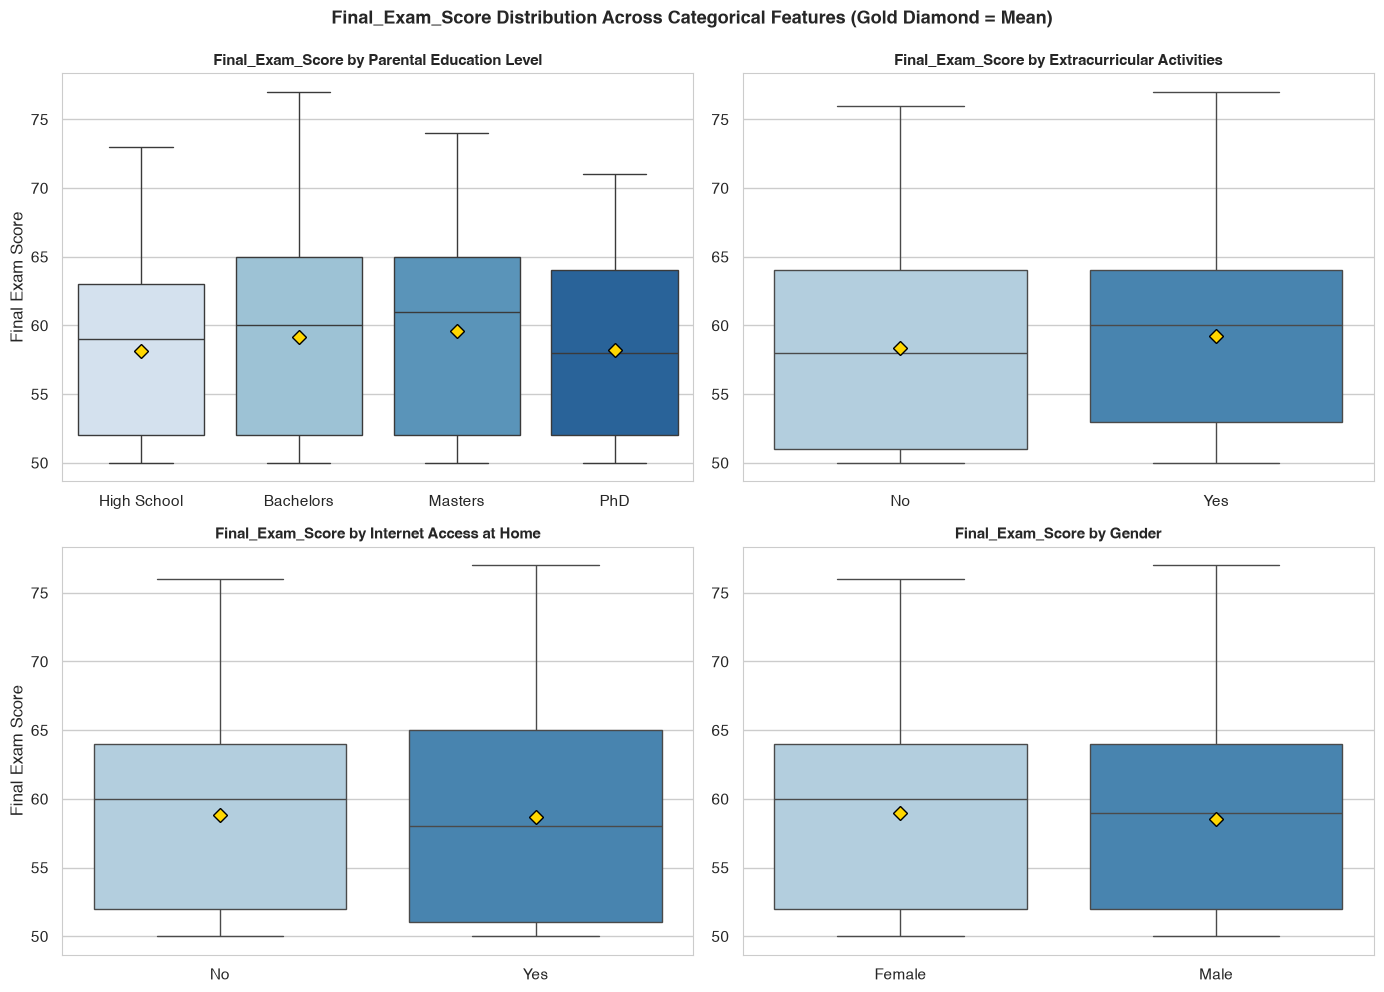

In [6]:
# Categorical columns
categorical_cols = ['Parental_Education_Level', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Gender']

# Custom ordering for educational level
cat_orders = {
    'Parental_Education_Level': ['High School', 'Bachelors', 'Masters', 'PhD'],
    'Extracurricular_Activities': ['No', 'Yes'],
    'Internet_Access_at_Home': ['No', 'Yes'],
    'Gender': ['Female', 'Male']
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

palette = sns.color_palette("Blues_r", 4)

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    order = cat_orders.get(col, None)
    
    sns.boxplot(
        data=df,
        x=col,
        y='Final_Exam_Score',
        order=order,
        ax=ax,
        palette="Blues",
        showmeans=True,
        meanprops={"marker": "D", "markeredgecolor": "black", "markerfacecolor": "gold", "markersize": "7"}
    )
    
    # Compute group statistics
    group_stats = df.groupby(col)['Final_Exam_Score'].agg(['mean', 'median', 'count'])
    if order:
        group_stats = group_stats.reindex(order)
        
    ax.set_title(f"Final_Exam_Score by {col.replace('_', ' ')}", fontsize=11, weight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Final Exam Score" if i % 2 == 0 else "")
    
    # Print numerical group stats
    print(f"=== Group Statistics: {col} ===")
    print(group_stats.round(2))
    print()

plt.suptitle("Final_Exam_Score Distribution Across Categorical Features (Gold Diamond = Mean)", fontsize=13, weight='bold', y=0.99)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_categorical_boxplots.png", dpi=300)
plt.show()


## 6. Summary of Key Findings

1. **Clean & Complete Dataset**: The dataset comprises **708 students and 10 features** with **zero missing values** across all columns. No imputation is required, simplifying preprocessing pipelines.
2. **Deterministic Binary Threshold**: The target `Final_Exam_Score` ranges strictly between **50 and 77** (Mean: **58.77**, Std: **6.71**). The dataset exhibits a perfect deterministic boundary: students with scores $\ge 60$ are classified as **Pass** (354 students, $50.0\%$), while those scoring $< 60$ are classified as **Fail** (354 students, $50.0\%$). No scores exceed 100 or drop below 0.
3. **Primary Numeric Predictors**: Linear correlation reveals strong predictive alignment:
   - **`Past_Exam_Scores` ($r = 0.490$)**: Prior academic achievement is the single strongest predictor of final exam performance.
   - **`Attendance_Rate` ($r = 0.460$)**: Consistent class presence strongly reinforces score gains.
   - **`Study_Hours_per_Week` ($r = 0.370$)**: Dedicated study time positively drives exam outcomes.
4. **Subtle Categorical Differentials**: Categorical features exhibit subtle yet realistic effects:
   - Students engaging in **`Extracurricular_Activities`** achieve higher mean scores (59.23 vs. 58.33) and higher pass rates ($55.3\%$ vs. $44.9\%$).
   - **`Parental_Education_Level`** shows peak average scores for students whose parents hold a Master's degree (59.59) and Bachelor's degree (59.13).
   - **`Gender`** shows virtually identical distributions (Female mean: 58.98 vs. Male mean: 58.54), demonstrating minimal demographic bias.
5. **Modeling Implications for XAI & SHAP**:
   - `Student_ID` must be removed as an identification artifact.
   - Continuous features should be normalized/scaled, and categorical attributes encoded via OneHotEncoder in a leak-free scikit-learn Pipeline.
   - Because `Past_Exam_Scores`, `Attendance_Rate`, and `Study_Hours_per_Week` drive the majority of variance, Tree Explainer (SHAP) is poised to cleanly identify these tangible, student-actionable behaviors for the LLM explanation layer.
